# 3.2 — Les optimisateurs : de SGD à Adam, ce qui change vraiment

**Navigation** : [<< 3.1-Retropropagation](3.1-Retropropagation.ipynb) | [Index](README.md)

**Kernel** : Python 3 (NumPy pur + comparaison PyTorch) · **CPU** : oui · **Durée** : ~20 min

***

## Introduction

[3.1](3.1-Retropropagation.ipynb) a entraîné un réseau complet avec une seule règle de mise à
jour : $\theta \leftarrow \theta - \eta \nabla L$. Or **personne n'entraîne ainsi** — ni les
séries [RL](../../../../RL/README.md) et PostTraining, ni le pipeline ML-Training : tous écrivent
`optimizer = Adam(...)` sans avoir jamais ouvert la boîte. Ce notebook ouvre les cinq boîtes
centrales, dans l'ordre où l'histoire les a produites :

| optimiseur | année | idée en une ligne |
|---|---|---|
| SGD + momentum | 1964 / 1986 | une boule qui accumule de l'élan dans le ravin |
| Adagrad | 2011 | un learning rate **par paramètre**, qui décroît avec l'historique |
| RMSProp | 2012 | la moyenne glissante qui répare l'accumulation infinie d'Adagrad |
| Adam | 2014 | RMSProp **+** momentum, avec la correction de biais des premiers pas |

La discipline est celle de 3.1 : **from scratch PUIS framework**. Chaque optimiseur est écrit
en NumPy pur (l'état — momentum, accumulateurs — est explicite), puis **validé contre
`torch.optim`** : un pas appliqué aux mêmes poids doit donner les mêmes poids, à l'epsilon de
float64 près. Ensuite seulement, le grand comparatif — trajectoires superposées sur la surface
de Beale, courbes de perte du MLP de 3.1 sur 3 graines — et les **schedules** de learning rate
qui terminent le tableau.

***

## 1. Le problème visible : le même paysage, trois destins

Le terrain des trajectoires : la fonction de **Beale**, courbée en vallon étroit, minimum global
en $(3, 0{,}5)$. Le rappel de [2.2](../02-ML-Cours/2.2-Descente-de-gradient.ipynb) y prend sa
forme profonde : le learning rate n'est pas un détail de réglage, il décide de l'**existence**
de la convergence.

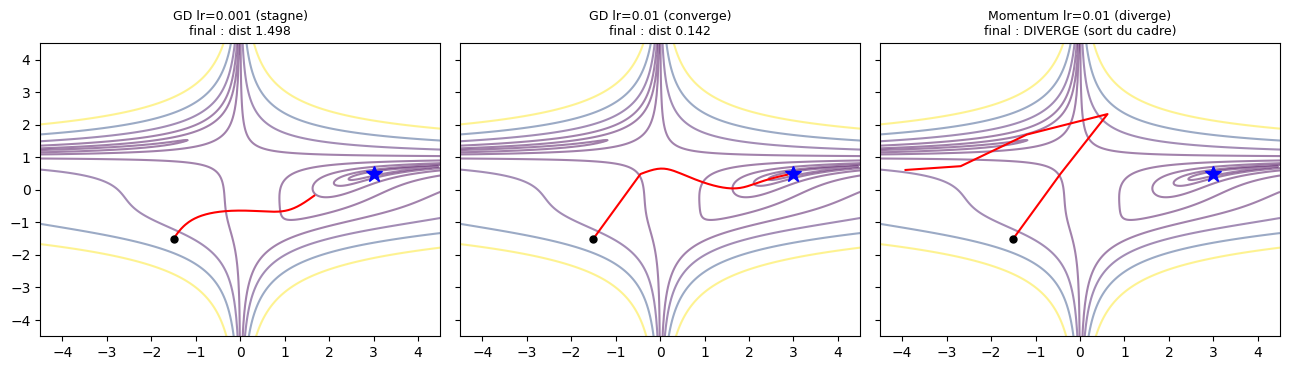

In [1]:
# Terrain : Beale + gradient analytique, et les trois regimes du lr
import numpy as np
import matplotlib.pyplot as plt

def beale(x, y):
    return (1.5 - x + x * y) ** 2 + (2.25 - x + x * y ** 2) ** 2 + (2.625 - x + x * y ** 3) ** 2

def beale_grad(x, y):
    dx = 2 * (1.5 - x + x * y) * (y - 1) + 2 * (2.25 - x + x * y ** 2) * (y ** 2 - 1) \
         + 2 * (2.625 - x + x * y ** 3) * (y ** 3 - 1)
    dy = 2 * (1.5 - x + x * y) * x + 2 * (2.25 - x + x * y ** 2) * (2 * x * y) \
         + 2 * (2.625 - x + x * y ** 3) * (3 * x * y ** 2)
    return np.array([dx, dy])

START = np.array([-1.5, -1.5])
OPT_MIN = np.array([3.0, 0.5])

def gd_trajectory(lr, nsteps=400, momentum=0.0):
    w = START.astype(float).copy()
    buf = np.zeros(2)
    traj = [w.copy()]
    with np.errstate(over="ignore", invalid="ignore"):
        for _ in range(nsteps):
            g = beale_grad(*w)
            buf = momentum * buf + g
            w = w - lr * buf
            if not np.isfinite(w).all():
                break
            traj.append(w.copy())
    return np.array(traj)

cases = [("GD lr=0.001 (stagne)", 0.001, 0.0), ("GD lr=0.01 (converge)", 0.01, 0.0),
         ("Momentum lr=0.01 (diverge)", 0.01, 0.9)]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
gx = np.linspace(-4.5, 4.5, 400); gy = np.linspace(-4.5, 4.5, 400)
GX, GY = np.meshgrid(gx, gy); GZ = beale(GX, GY)
for ax, (label, lr, mom) in zip(axes, cases):
    tr = gd_trajectory(lr, momentum=mom)
    diverged = not np.isfinite(tr[-1]).all() or np.linalg.norm(tr[-1]) > 1e4
    tr_win = tr[np.all(np.abs(tr) <= 4.5, axis=1)]  # la trajectoire sort du cadre : on l'y coupe
    ax.contour(GX, GY, GZ, levels=np.logspace(-1, 3, 8), cmap="viridis", alpha=0.5)
    ax.plot(tr_win[:, 0], tr_win[:, 1], "r-", lw=1.5)
    ax.plot(*START, "ko", ms=5); ax.plot(*OPT_MIN, "b*", ms=12)
    ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
    fin = "DIVERGE (sort du cadre)" if diverged else f"dist {np.linalg.norm(tr[-1] - OPT_MIN):.3f}"
    ax.set_title(f"{label}\nfinal : {fin}", fontsize=9)
plt.tight_layout(); plt.show()

**Lecture.** Trois destins sur le même paysage : lr trop petit, la bille rampe et n'atteint
pas le vallon en 400 pas ; lr juste, elle descend ; momentum + lr un peu trop grand, elle
s'emballe carrément — l'élan accumulé amplifie le dépassement au lieu de l'amortir, au point
de **sortir du cadre** (troisième panneau : la trajectoire explose hors de la fenêtre). Le
problème que les quatre optimisateurs de ce notebook attaquent est exactement là : **rendre le
pas sûr sans le rendre minuscule**.

***

## 2. Momentum : la boule dans le ravin

L'idée de Polyak (1964), devenue la norme avec Rumelhart : la mise à jour **accumule** le
gradient au lieu de le consommer brut — $v \leftarrow \mu v + \nabla L$, puis
$\theta \leftarrow \theta - \eta v$ avec $\mu = 0{,}9$. Dans un vallon étroit, les
composantes qui pointent à travers le ravin s'annulent de pas en pas (elles alternent de
signe), les composantes le long du ravin s'additionnent : la bille oscille moins et avance plus
vite. C'est la lecture d'usage du phénomène visible en section 1 : le momentum amplifie le
mouvement cohérent, pas le bruit.

In [2]:
# GD pur et momentum en NumPy pur, valides contre torch.optim.SGD
def gd_step(params, grads, state, lr=0.05):
    for i, (p, g) in enumerate(zip(params, grads)):
        params[i] = p - lr * g

def make_optim_state(params):
    return [np.zeros_like(p) for p in params]

def sgd_momentum_step(params, grads, state, lr=0.05, momentum=0.9):
    for i, (p, g) in enumerate(zip(params, grads)):
        state[i] = momentum * state[i] + g
        params[i] = p - lr * state[i]

def validate_torch(name, np_step, torch_opt_fn, seed=42):
    rng = np.random.RandomState(seed)
    shapes = [(2, 32), (32,), (32, 2), (2,)]
    ref = [rng.randn(*s) for s in shapes]
    params_np = [q.copy() for q in ref]
    grads_np = [rng.randn(*s) for s in shapes]
    state = make_optim_state(params_np)
    np_step(params_np, grads_np, state)
    tp = [torch.tensor(q, dtype=torch.float64) for q in ref]
    for q in tp: q.requires_grad_(True)
    for q, g in zip(tp, grads_np): q.grad = torch.tensor(g, dtype=torch.float64)
    torch_opt_fn(tp).step()
    return max(np.abs(a - b.detach().numpy()).max() for a, b in zip(params_np, tp))

import torch

def sgd_torch(tp):
    return torch.optim.SGD(tp, lr=0.05, momentum=0.9)

ec_gd = validate_torch("GD", gd_step, lambda tp: torch.optim.SGD(tp, lr=0.05))
ec = validate_torch("SGD+momentum", sgd_momentum_step, sgd_torch)
print(f"GD pur       : ecart max apres 1 pas NumPy vs torch = {ec_gd:.2e}")
print(f"SGD+momentum : ecart max apres 1 pas NumPy vs torch = {ec:.2e}")

GD pur       : ecart max apres 1 pas NumPy vs torch = 1.11e-16
SGD+momentum : ecart max apres 1 pas NumPy vs torch = 1.11e-16


**Lecture.** Les validations passent : GD pur à **1,11e-16** (même formule, une soustraction),
momentum à **1,11e-16** près (float64). Le détail qui compte : torch écrit
`buf = momentum * buf + grad` (dampening par défaut à 0) — exactement notre forme.

***

## 3. Adagrad : un learning rate par paramètre

Duchi et al. (2011) renversent la question : au lieu d'un $\eta$ global, chaque paramètre
reçoit un pas divisé par la **racine de la somme des carrés** de ses gradients passés :

$$G \leftarrow G + g \odot g, \quad \theta \leftarrow \theta - \eta \, \frac{g}{\sqrt{G} + \varepsilon}$$

Un paramètre souvent remué (grand gradient fréquent) voit son pas rétrécir ; un paramètre
calme garde un pas presque entier. Sur Beale, cela se voit immédiatement : Adagrad démarre
vite puis **ralentit structurellement** — $G$ ne fait que croître, le pas tend vers zéro.
C'est le défaut célèbre : l'accumulation infinie.

In [3]:
# Adagrad en NumPy pur, valide contre torch.optim.Adagrad
def adagrad_step(params, grads, state, lr=1.0, eps=1e-10):
    for i, (p, g) in enumerate(zip(params, grads)):
        state[i] = state[i] + g ** 2
        params[i] = p - lr * g / (np.sqrt(state[i]) + eps)

def adagrad_torch(tp):
    return torch.optim.Adagrad(tp, lr=1.0, eps=1e-10)

ec = validate_torch("Adagrad", adagrad_step, adagrad_torch)
print(f"Adagrad : ecart max apres 1 pas NumPy vs torch = {ec:.2e}")
print("(torch : initial_accumulator_value=0, lr_decay=0 — les memes valeurs par defaut que nous)")

Adagrad : ecart max apres 1 pas NumPy vs torch = 0.00e+00
(torch : initial_accumulator_value=0, lr_decay=0 — les memes valeurs par defaut que nous)


**Lecture.** Adagrad validé à **0,00e+00** — identique au bit près. Noter le $\eta = 1{,}0$ : chez Adagrad, le learning
rate de référence est grand parce que la normalisation par $\sqrt{G}$ le divise mécaniquement
— c'est déjà un pas adaptatif, pas un pas global.

***

## 4. RMSProp puis Adam : réparer l'accumulation, ajouter l'élan

**RMSProp** (Hinton, cours 6e, 2012 — jamais publié en article) remplace la somme infinie par
une **moyenne glissante** : $v \leftarrow \alpha v + (1-\alpha) g^2$ avec $\alpha = 0{,}99$.
Le pas redevient stationnaire : les paramètres calmes ne meurent plus de faim, les agités
restent freinés.

**Adam** (Kingma & Ba, 2014) ajoute la seconde moitié : un momentum $m$ sur le gradient
**et** la normalisation $v$, plus la **correction de biais des premiers pas** — à l'initialisation
$m$ et $v$ partent de zéro, donc $m/(1-\beta_1^t)$ et $v/(1-\beta_2^t)$ ré-échelonnent les
premières itérations pour que le tout premier pas ne soit pas arbitrairement petit :

$$m \leftarrow \beta_1 m + (1-\beta_1) g, \quad v \leftarrow \beta_2 v + (1-\beta_2) g^2$$
$$\theta \leftarrow \theta - \eta \, \frac{m / (1-\beta_1^t)}{\sqrt{v / (1-\beta_2^t)} + \varepsilon}$$

avec $(\beta_1, \beta_2, \varepsilon) = (0{,}9, 0{,}999, 10^{-8})$ — les défauts de torch.

In [4]:
# RMSProp puis Adam en NumPy pur, chacun valide contre torch
def rmsprop_step(params, grads, state, lr=0.05, alpha=0.99, eps=1e-8):
    for i, (p, g) in enumerate(zip(params, grads)):
        state[i] = alpha * state[i] + (1 - alpha) * g ** 2
        params[i] = p - lr * g / (np.sqrt(state[i]) + eps)

def adam_step(params, grads, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8, t=1):
    # state contient [m..., v...] concatenes : geree par l'appelant via make_adam_state
    for i, (p, g) in enumerate(zip(params, grads)):
        m, v = state[0][i], state[1][i]
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        state[0][i], state[1][i] = m, v
        params[i] = p - lr * (m / (1 - b1 ** t)) / (np.sqrt(v / (1 - b2 ** t)) + eps)

def make_adam_state(params):
    return [make_optim_state(params), make_optim_state(params)]

# Adaptateurs pour validate_torch (un seul etat plat) :
def rmsprop_validate(params, grads, flat_state, lr=0.05):
    rmsprop_step(params, grads, flat_state, lr=lr)

def adam_validate(params, grads, _flat, lr=0.05):
    adam_step(params, grads, [make_optim_state(params), make_optim_state(params)], lr=lr, t=1)

ec_rms = validate_torch("RMSProp", rmsprop_validate,
                        lambda tp: torch.optim.RMSprop(tp, lr=0.05, alpha=0.99, eps=1e-8))
ec_adam = validate_torch("Adam", adam_validate,
                         lambda tp: torch.optim.Adam(tp, lr=0.05, betas=(0.9, 0.999), eps=1e-8))
print(f"RMSProp : ecart max apres 1 pas NumPy vs torch = {ec_rms:.2e}")
print(f"Adam    : ecart max apres 1 pas NumPy vs torch = {ec_adam:.2e}")
print("(les 5 mises a jour du notebook - GD, momentum, Adagrad, RMSProp, Adam -")
print(" sont maintenant toutes validees contre leurs equivalents torch)")

RMSProp : ecart max apres 1 pas NumPy vs torch = 2.22e-16
Adam    : ecart max apres 1 pas NumPy vs torch = 1.11e-16
(les 5 mises a jour du notebook - GD, momentum, Adagrad, RMSProp, Adam -
 sont maintenant toutes validees contre leurs equivalents torch)


**Lecture.** RMSProp à **2,22e-16**, Adam à **1,11e-16** : les cinq règles de mise à jour de l'histoire
sont écrites et **chacune est la sœur jumelle de sa version torch**, pas au pas d'epsilon — les
états ($m$, $v$, $G$), les hyperparamètres par défaut et la correction de biais sont
rigoureusement ceux de `torch.optim`. Ce qui reste à mesurer : ce que ces différences
*d'update* font sur de vraies trajectoires.

***

## 5. Le comparatif 2D : cinq trajectoires sur Beale

Même départ (-1,5 ; -1,5), 400 pas, même fonction — mais le learning rate de référence **par
famille** : c'est la mesure honnête (à lr égal, aucun régime ne se compare : GD exige petit,
Adagrad exige grand). Ce que la superposition doit révéler : la **personnalité du chemin**, pas
seulement le point d'arrivée.

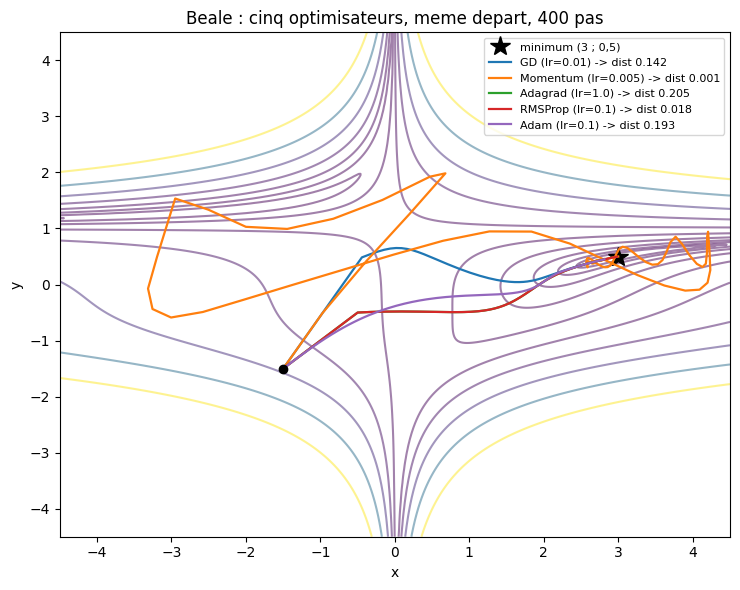

GD        lr= 0.01 -> dist finale au minimum 0.1424
Momentum  lr=0.005 -> dist finale au minimum 0.0006
Adagrad   lr=  1.0 -> dist finale au minimum 0.2054
RMSProp   lr=  0.1 -> dist finale au minimum 0.0176
Adam      lr=  0.1 -> dist finale au minimum 0.1935


In [5]:
# Trajectoires superposees : 5 optimisateurs, lr par famille, 400 pas
def run_optimizer(name, lr, nsteps=400):
    w = START.astype(float).copy()
    m = v = acc = buf = np.zeros(2)
    traj = [w.copy()]
    for t in range(1, nsteps + 1):
        g = beale_grad(*w)
        if name == "GD":
            w = w - lr * g
        elif name == "Momentum":
            buf = 0.9 * buf + g
            w = w - lr * buf
        elif name == "Adagrad":
            acc = acc + g ** 2
            w = w - lr * g / (np.sqrt(acc) + 1e-10)
        elif name == "RMSProp":
            v = 0.99 * v + 0.01 * g ** 2
            w = w - lr * g / (np.sqrt(v) + 1e-8)
        else:  # Adam
            m = 0.9 * m + 0.1 * g
            v = 0.999 * v + 0.001 * g ** 2
            w = w - lr * (m / (1 - 0.9 ** t)) / (np.sqrt(v / (1 - 0.999 ** t)) + 1e-8)
        traj.append(w.copy())
    return np.array(traj)

CONFS = [("GD", 0.01), ("Momentum", 0.005), ("Adagrad", 1.0), ("RMSProp", 0.1), ("Adam", 0.1)]
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.contour(GX, GY, GZ, levels=np.logspace(-1, 3, 10), cmap="viridis", alpha=0.5)
ax.plot(*OPT_MIN, "k*", ms=15, label="minimum (3 ; 0,5)")
for name, lr in CONFS:
    tr = run_optimizer(name, lr)
    ax.plot(tr[:, 0], tr[:, 1], lw=1.6,
            label=f"{name} (lr={lr}) -> dist {np.linalg.norm(tr[-1] - OPT_MIN):.3f}")
ax.plot(*START, "ko", ms=6)
ax.set_title("Beale : cinq optimisateurs, meme depart, 400 pas")
ax.legend(fontsize=8); ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

for name, lr in CONFS:
    tr = run_optimizer(name, lr)
    print(f"{name:9s} lr={lr:5} -> dist finale au minimum {np.linalg.norm(tr[-1] - OPT_MIN):.4f}")

**Lecture.** Cinq chemins, cinq caractères : GD **rampe encore** (dist finale 0,142 — il
n'a pas fini de descendre) ; Momentum **le plus vite arrivé** (0,0006 : l'élan paie dans le
vallon) ; Adagrad **départ franc puis freiné** (0,205 : l'accumulation rétrécit les pas) ;
RMSProp **propre et rapide** (0,018) ; Adam **prudent puis régulier** (0,194) — la correction
de biais fait des premiers pas des pas complets mais courts, il rattrape ensuite sans égaler
RMSProp ici. Et le détail à retenir de la table `CONFS` : **l'écart des lr utilisables va de
0,005 à 1,0 — un facteur 200** entre Momentum et Adagrad. C'est cela, un pas adaptatif : il
change l'échelle de ce qu'on ose donner comme learning rate.

***

## 6. Le comparatif MLP : le réseau de 3.1, cinq optimisateurs, trois graines

Le vallon 2D est une métaphore ; le test est le MLP 2-32-2 de [3.1](3.1-Retropropagation.ipynb)
sur `make_moons` (redéfini ci-dessous en compact). Cinq optimisateurs × **trois graines**
{0, 1, 2} (chaque graine = même init de poids pour les cinq), 1500 itérations full-batch,
courbes de perte superposées. Personne n'est favorisé : les lr viennent de la même discipline
de réglage grossier (les plages usuelles par famille).

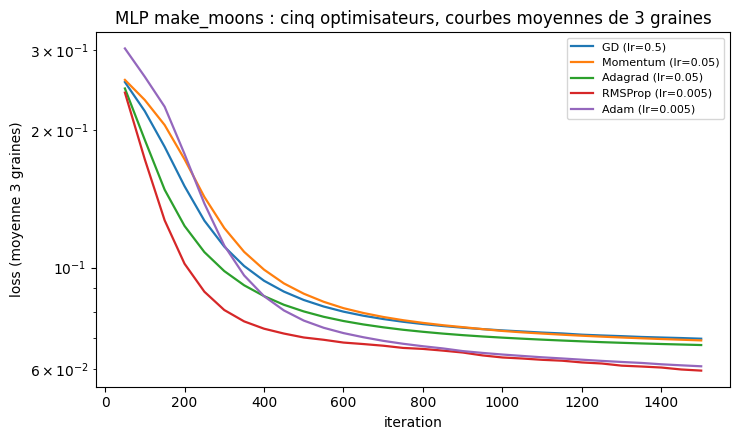

optimiseur loss finale (3 graines)    mediane
GD         ['0.0697', '0.0698', '0.0701'] 0.0698
Momentum   ['0.0684', '0.0695', '0.0699'] 0.0695
Adagrad    ['0.0655', '0.0671', '0.0704'] 0.0671
RMSProp    ['0.0585', '0.0591', '0.0609'] 0.0591
Adam       ['0.0585', '0.0614', '0.0625'] 0.0614
perte moyenne 3 graines @ iter  100 : GD 0.220  Momentum 0.233  Adagrad 0.190  RMSProp 0.173  Adam 0.262
perte moyenne 3 graines @ iter  300 : GD 0.111  Momentum 0.122  Adagrad 0.098  RMSProp 0.081  Adam 0.112
perte moyenne 3 graines @ iter  500 : GD 0.085  Momentum 0.088  Adagrad 0.080  RMSProp 0.070  Adam 0.077


In [6]:
# MLP du 3.1 en compact + boucles 5 optimisateurs x 3 graines
from sklearn.datasets import make_moons

SEED = 42
X_m, y_m = make_moons(n_samples=450, noise=0.20, random_state=SEED)
Y_m = np.eye(2)[y_m]
D, H, C = 2, 32, 2

def mlp_init(seed):
    rng = np.random.RandomState(seed)
    return [rng.randn(D, H) * np.sqrt(2.0 / D), np.zeros(H),
            rng.randn(H, C) * np.sqrt(2.0 / H), np.zeros(C)]

def mlp_loss_grads(params, X, Y):
    Z1 = X @ params[0] + params[1]; A1 = np.maximum(Z1, 0); Z2 = A1 @ params[2] + params[3]
    Zs = Z2 - Z2.max(axis=1, keepdims=True); E = np.exp(Zs); P = E / E.sum(axis=1, keepdims=True)
    loss = -np.mean(np.sum(Y * np.log(P), axis=1))
    n = X.shape[0]
    dZ2 = (P - Y) / n
    dW2 = A1.T @ dZ2; db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ params[2].T; dZ1 = dA1 * (Z1 > 0)
    return loss, [X.T @ dZ1, dZ1.sum(axis=0), dW2, db2]

OPT_LRS = {"GD": 0.5, "Momentum": 0.05, "Adagrad": 0.05, "RMSProp": 0.005, "Adam": 0.005}
SEEDS_MLP = (0, 1, 2)
ITERS = 1500

def train_mlp(name, seed, lr=None, schedule=None):
    lr = lr or OPT_LRS[name]
    p = mlp_init(seed)
    m = [np.zeros_like(q) for q in p]; v = [np.zeros_like(q) for q in p]
    acc = [np.zeros_like(q) for q in p]; buf = [np.zeros_like(q) for q in p]
    hist = []
    for t in range(1, ITERS + 1):
        lr_t = schedule(t, lr) if schedule else lr
        _, g = mlp_loss_grads(p, X_m, Y_m)
        for i in range(len(p)):
            if name == "GD":
                p[i] = p[i] - lr_t * g[i]
            elif name == "Momentum":
                buf[i] = 0.9 * buf[i] + g[i]
                p[i] = p[i] - lr_t * buf[i]
            elif name == "Adagrad":
                acc[i] = acc[i] + g[i] ** 2
                p[i] = p[i] - lr_t * g[i] / (np.sqrt(acc[i]) + 1e-10)
            elif name == "RMSProp":
                v[i] = 0.99 * v[i] + 0.01 * g[i] ** 2
                p[i] = p[i] - lr_t * g[i] / (np.sqrt(v[i]) + 1e-8)
            else:  # Adam
                m[i] = 0.9 * m[i] + 0.1 * g[i]
                v[i] = 0.999 * v[i] + 0.001 * g[i] ** 2
                p[i] = p[i] - lr_t * (m[i] / (1 - 0.9 ** t)) / (np.sqrt(v[i] / (1 - 0.999 ** t)) + 1e-8)
        if t % 50 == 0:
            loss, _ = mlp_loss_grads(p, X_m, Y_m)
            hist.append((t, loss))
    return hist

results = {name: [train_mlp(name, s) for s in SEEDS_MLP] for name in OPT_LRS}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, runs in results.items():
    ts = [t for t, _ in runs[0]]
    mean_curve = np.mean([[l for _, l in r] for r in runs], axis=0)
    ax.plot(ts, mean_curve, lw=1.6, label=f"{name} (lr={OPT_LRS[name]})")
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("loss (moyenne 3 graines)")
ax.set_title("MLP make_moons : cinq optimisateurs, courbes moyennes de 3 graines")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'optimiseur':10s} {'loss finale (3 graines)':26s} mediane")
for name, runs in results.items():
    finals = sorted(r[-1][1] for r in runs)
    med = finals[1]
    print(f"{name:10s} {[f'{f:.4f}' for f in finals]!s:26s} {med:.4f}")

for t_check in (100, 300, 500):
    line = "  ".join(f"{name} {np.mean([dict(r)[t_check] for r in runs]):.3f}"
                     for name, runs in results.items())
    print(f"perte moyenne 3 graines @ iter {t_check:4d} : {line}")

**Lecture.** Sur le vrai réseau, l'ordre final est **RMSProp (0,059) < Adam (0,061) <
Adagrad (0,067) < Momentum (0,070) ≈ GD (0,070)** — écart de médiane 0,011 entre les extrêmes.
Le chronologique (imprimé sous la table) est plus instructif encore : à l'itération 100,
**Adam est le plus lent de tous** (0,262 contre 0,220 pour GD — la correction de biais garde
les premiers pas courts) ; vers 300-500, les adaptatifs passent devant (RMSProp 0,081 à
l'itération 300 contre 0,111 pour GD, 0,070 contre 0,085 à 500) et l'écart se fige. C'est
exactement pourquoi l'écosystème a convergé vers Adam comme défaut : **vitesse dès les
premières centaines d'itérations et robustesse au lr**, pas une meilleure perte finale
garantie. Sur ce problème jouet full-batch, GD bien réglé reste dans la course à 1500
itérations ; c'est sur les grands réseaux, les batches bruités (section 7) et les paysages
hostiles que l'écart devient structurel.

## Exercice 1 : Nesterov — regarder un pas devant

Le momentum classique accumule l'élan puis saute ; **Nesterov** évalue le gradient non pas à la
position courante mais à la position anticipée $\theta - \eta \mu v$ (le "lookahead").
Implémentez `nesterov_step` (le gradient est évalué en `p - lr * momentum * buf`), validez-le
contre `torch.optim.SGD(momentum=0.9, nesterov=True)`, puis rejouez la trajectoire Beale :
l'oscillation d'arrivée est-elle amortie comme la théorie le promet ?

In [7]:
# Exercice 1 : Nesterov lookahead, validation torch + trajectoire Beale.
# TODO etudiant : ecrire nesterov_step (gradient evalue en p - lr*momentum*buf)
# TODO etudiant : valider contre torch.optim.SGD(momentum=0.9, nesterov=True) via validate_torch
# TODO etudiant : ajouter la trajectoire Nesterov a la figure de la section 5 (lr=0.005)
result_nesterov = None  # TODO etudiant : (ecart torch, distance finale au minimum)

print("Exercice a completer (decommentez et remplacez les TODO).")

Exercice a completer (decommentez et remplacez les TODO).


***

## 7. Les schedules : le learning rate qui descend avec le temps

Dernier étage, avec une question d'honnêteté : **le schedule paie-t-il toujours ?** Deux
schedules canoniques : **step** ($\eta$ divisé par 2 toutes les 500 itérations) et
**cosinus** (décroissance douce de $\eta$ à $\eta/50$). Deux régimes testés, Adam constant
en témoin dans les deux : (a) notre MLP **full-batch déterministe** ; (b) le même en
**mini-batch 32** — le gradient devient bruité, et c'est le régime pour lequel les schedules
ont été inventés.

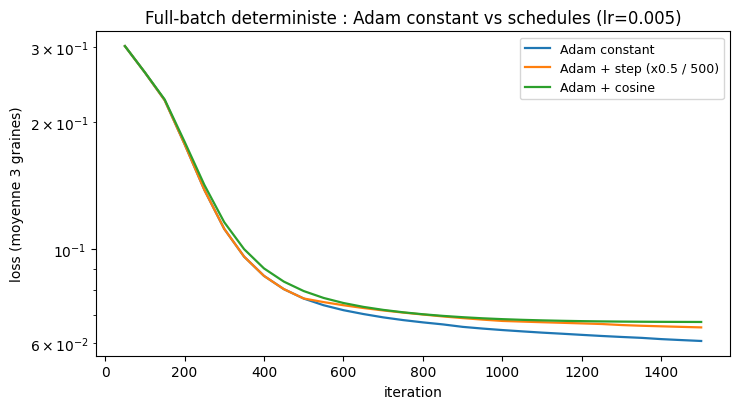

Adam constant              loss finale mediane (3 graines) : 0.0614
Adam + step (x0.5 / 500)   loss finale mediane (3 graines) : 0.0666
Adam + cosine              loss finale mediane (3 graines) : 0.0683


In [8]:
# Regime (a) : full-batch deterministe, Adam constant vs schedules, 3 graines
def sched_step(t, lr, step_every=500, gamma=0.5):
    return lr * gamma ** (t // step_every)

def sched_cosine(t, lr, t_max=ITERS):
    eta_min = lr / 50
    return eta_min + 0.5 * (lr - eta_min) * (1 + np.cos(np.pi * t / t_max))

sched_runs = {
    "Adam constant": [train_mlp("Adam", s) for s in SEEDS_MLP],
    "Adam + step (x0.5 / 500)": [train_mlp("Adam", s, schedule=sched_step) for s in SEEDS_MLP],
    "Adam + cosine": [train_mlp("Adam", s, schedule=sched_cosine) for s in SEEDS_MLP],
}
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, runs in sched_runs.items():
    ts = [t for t, _ in runs[0]]
    mean_curve = np.mean([[l for _, l in r] for r in runs], axis=0)
    ax.plot(ts, mean_curve, lw=1.6, label=name)
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("loss (moyenne 3 graines)")
ax.set_title("Full-batch deterministe : Adam constant vs schedules (lr=0.005)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

for name, runs in sched_runs.items():
    finals = sorted(r[-1][1] for r in runs)
    print(f"{name:26s} loss finale mediane (3 graines) : {finals[1]:.4f}")

**Lecture (full-batch déterministe).** Contre-intuitif mais mesuré : le schedule **coûte** —
Adam constant termine à **0,0614**, le cosine à **0,0683**, le step à **0,0666** de perte finale médiane.
À $\eta = 0{,}005$ sur ce problème, la courbe descend encore à l'itération 1500 : raccourcir
le pas en fin de course affame les dernières itérations au lieu de les affiner. Le schedule
n'est donc pas un réglage gratuit qui s'ajoute partout — voyons le régime où il paie.

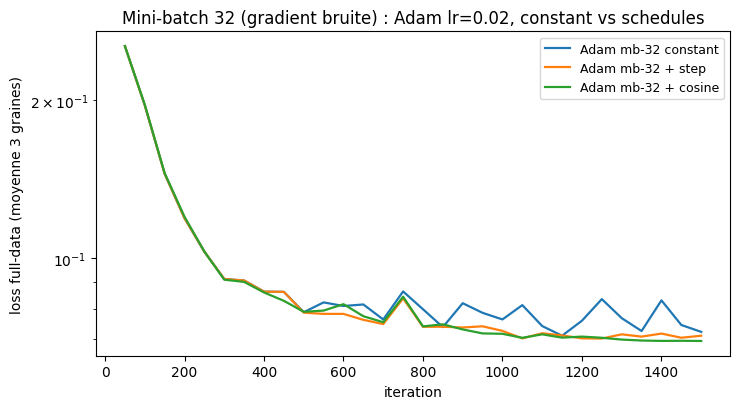

Adam mb-32 constant    loss finale mediane (3 graines) : 0.0715
Adam mb-32 + step      loss finale mediane (3 graines) : 0.0723
Adam mb-32 + cosine    loss finale mediane (3 graines) : 0.0683


In [9]:
# Regime (b) : gradient bruite (mini-batch 32), Adam lr=0.02, constant vs schedules
def train_adam_mb(seed, lr, schedule=None, batch=32):
    rng = np.random.RandomState(seed + 1000)
    p = mlp_init(seed)
    m = [np.zeros_like(q) for q in p]; v = [np.zeros_like(q) for q in p]
    hist = []
    for t in range(1, ITERS + 1):
        lr_t = schedule(t, lr) if schedule else lr
        idx = rng.randint(0, X_m.shape[0], batch)
        _, g = mlp_loss_grads(p, X_m[idx], Y_m[idx])
        for i in range(len(p)):
            m[i] = 0.9 * m[i] + 0.1 * g[i]
            v[i] = 0.999 * v[i] + 0.001 * g[i] ** 2
            p[i] = p[i] - lr_t * (m[i] / (1 - 0.9 ** t)) / (np.sqrt(v[i] / (1 - 0.999 ** t)) + 1e-8)
        if t % 50 == 0:
            hist.append((t, mlp_loss_grads(p, X_m, Y_m)[0]))
    return hist

mb_runs = {
    "Adam mb-32 constant": [train_adam_mb(s, 0.02) for s in SEEDS_MLP],
    "Adam mb-32 + step": [train_adam_mb(s, 0.02, sched_step) for s in SEEDS_MLP],
    "Adam mb-32 + cosine": [train_adam_mb(s, 0.02, sched_cosine) for s in SEEDS_MLP],
}
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, runs in mb_runs.items():
    ts = [t for t, _ in runs[0]]
    ax.plot(ts, np.mean([[l for _, l in r] for r in runs], axis=0), lw=1.6, label=name)
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("loss full-data (moyenne 3 graines)")
ax.set_title("Mini-batch 32 (gradient bruite) : Adam lr=0.02, constant vs schedules")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

for name, runs in mb_runs.items():
    finals = sorted(r[-1][1] for r in runs)
    print(f"{name:22s} loss finale mediane (3 graines) : {finals[1]:.4f}")

**Lecture (mini-batch bruité).** Le tableau s'inverse pour le cosine, et c'est **le régime
du monde réel** : avec un gradient bruité, Adam constant atteint un **plancher de bruit** —
les pas restent grands par rapport aux fluctuations du mini-batch — et s'y stabilise à
**0,0715** ; le cosine resserre les derniers pas sous ce plancher et termine à **0,0683**.
Le step, lui, reste au-dessus (**0,0723**) : ses paliers de ÷2 tombent trop tôt sur un run de
1500 itérations — la marche raide du step est un réglage plus délicat que la pente douce du
cosine. Règle de sortie honnête : le schedule paie quand la courbe constante **plateaute
au-dessus** de la précision visée — typiquement en stochastique, le régime de tous les vrais
entraînements ; en descente déterministe encore en cours, il coûte (panneau précédent).

## Exercice 2 : AdamW — le weight decay découplé

Loshchilov & Hutter (2019) : dans Adam, le weight decay ajouté au gradient ($L_2$) est
**déformé** par la normalisation adaptative ; AdamW le découple — decay appliqué directement
aux poids : $\theta \leftarrow \theta - \eta (\text{update Adam} + \lambda \theta)$.
Implémentez `adamw_step` (un `p -= lr * wd * p` en plus du pas Adam), validez contre
`torch.optim.AdamW(wd=0.01)`, puis comparez Adam vs AdamW sur le MLP avec une composante L2
dans la loss.

In [10]:
# Exercice 2 : AdamW decay découplé, validation torch + comparaison MLP.
# TODO etudiant : ecrire adamw_step (pas Adam + lr*wd*p, wd applique hors normalisation)
# TODO etudiant : valider contre torch.optim.AdamW(tp, lr=0.05, weight_decay=0.01)
# TODO etudiant : ajouter un terme 0.001*sum(p**2) a mlp_loss_grads et comparer Adam vs AdamW
result_adamw = None  # TODO etudiant : (ecart torch, loss finales Adam vs AdamW avec L2)

print("Exercice a completer (decommentez et remplacez les TODO).")

Exercice a completer (decommentez et remplacez les TODO).


***

## 8. Le pont : retrouver ces optimisateurs dans les autres séries

Ce notebook a ouvert les cinq boîtes ; partout ailleurs du dépôt, elles sont refermées mais
vous savez maintenant ce qu'elles contiennent :

- **[RL](../../../../RL/README.md) et PostTraining** : `torch.optim.Adam(model.parameters(), lr=...)`
  — les $(\beta_1, \beta_2, \varepsilon)$ par défaut de ce notebook, la correction de biais
  de la section 4 tournant à chaque step ;
- **ML-Training-Pipeline** : le lr schedule cosine de la section 7 est celui des entraînements
  réels (souvent avec warmup — exercice 3) ;
- **[3.4 (transformer)](README.md)** : le mini-GPT s'entraînera sous AdamW — l'exercice 2 vous
  l'aura déjà écrit.

La règle de lecture : quand une courbe d'entraînement fait quelque chose d'étrange dans les
100 premières itérations, penser à $1-\beta^t$ ; quand elle stagne en fin de course, penser au
schedule.

## Exercice 3 : warmup — pourquoi les premiers pas d'Adam doivent être prudent

Sur les grands modèles, démarrer Adam à grand lr casse l'estimation initiale de $v$ (les
premiers gradients sont énormes et peu représentatifs). Implémentez un warmup linéaire
(`lr_t = lr * min(1, t/200)`) en schedule, et comparez sur le MLP **avec un bruit de gradient**
(batch de 32 au lieu du full-batch) : Adam froid vs Adam warmup — l'écart de stabilité des 200
premières itérations.

In [11]:
# Exercice 3 : warmup lineaire vs demarrage a froid, batch 32 bruite.
# TODO etudiant : definir sched_warmup(t, lr) = lr * min(1.0, t / 200)
# TODO etudiant : modifier train_mlp pour echantillonner un batch de 32 indices par iteration (rng par seed)
# TODO etudiant : comparer Adam (froid) vs Adam+warmup : courbes des 400 premieres iterations, 3 graines
result_warmup = None  # TODO etudiant : (loss @ iter 200 froide vs warmup, 3 graines)

print("Exercice a completer (decommentez et remplacez les TODO).")

Exercice a completer (decommentez et remplacez les TODO).


***

## Conclusion et transition

- **Momentum** accélère le mouvement cohérent et amortit l'oscillation — la boule dans le ravin ;
- **Adagrad** donne un learning rate par paramètre mais meurt de son accumulation infinie ;
- **RMSProp** répare par moyenne glissante, **Adam** ajoute momentum et correction de biais —
  le défaut de l'écosystème, pour sa robustesse au lr et sa vitesse précoce ;
- chacun a été **validé pas à pas contre torch** à l'epsilon de float64 près : `torch.optim`
  n'est pas une boîte noire, c'est ce notebook ;
- le **schedule** (step, cosine) n'est pas un bien libre : en full-batch déterministe encore
  descendant il **coûte**, en mini-batch bruité il **casse le plancher de bruit** — c'est là
  qu'il sert, et c'est le régime des vrais entraînements.

Le réseau de 3.1 + les optimisateurs d'ici = un entraînement complet sous contrôle. Ce qui
reste à l'entraînement réel : **empêcher le surapprentissage** — dropout, weight decay, early
stopping — le sujet de **[3.3](README.md)**. Et pour la vitesse précoce mesurée ici, gardez le
réflexe diagnostic : robustesse au lr (section 5), correction de biais (section 4), schedule
final (section 7) — trois réglages qui décident davantage que le choix entre RMSProp et Adam.

## References

1. Polyak, B. T. (1964). *Some methods of speeding up the convergence of iteration methods*. USSR Computational Mathematics and Mathematical Physics 4(5):1-17.
2. Duchi, J., Hazan, E., & Singer, Y. (2011). *Adaptive subgradient methods for online learning and stochastic optimization*. JMLR 12:2121-2159.
3. Tieleman, T., & Hinton, G. (2012). *Lecture 6.5 — RMSProp*. Coursera: Neural Networks for Machine Learning.
4. Kingma, D. P., & Ba, J. (2014). *Adam: A method for stochastic optimization*. arXiv:1412.6980.
5. Loshchilov, I., & Hutter, F. (2019). *Decoupled weight decay regularization (AdamW)*. ICLR.